# EDA PROJECT 

Importing libraries required till data manipulation and cleaning : 

* requests - to send request to https website server
* pandas - to work on data manipulation and data cleaning
* numpy - to work on numerical data
* re - to use regex module on data
* json - to work with json files 

In [2]:
import requests 
import pandas as pd 
import numpy as np 
import re 
import json

In [3]:
import warnings 
warnings.filterwarnings('ignore')


In [99]:
url = "https://openlibrary.org/search"

In [100]:
response = requests.get(url)
response

<Response [200]>

# NOTE : 
* While exploring website we found out it has public api key 
go to open library website - go to menu - resources - developer center - web Apis - json 

# sending requests to the website using api key 

In [5]:
url = "https://openlibrary.org/search.json"

all_books = []

for page in range(1,21):   # 20 pages
    params = {
        "q": "python programming", #parameters 
        "limit": 100,
        "page": page
    }

    response = requests.get(url, params=params)
    data = response.json()

    all_books.extend(data["docs"])

# Creating a DF using json_normalize 

In [102]:
df = pd.json_normalize(all_books)

print('DataFrame Shape:',df.shape)

df

DataFrame Shape: (2000, 18)


,author_key,author_name,cover_edition_key,cover_i,ebook_access,edition_count,first_publish_year,has_fulltext,key,language,public_scan_b,title,ia,ia_collection,lending_edition_s,lending_identifier_s,subtitle,id_project_gutenberg
0,[OL11300208A],[R. Nageswara Rao],OL42461457M,13192647.0,no_ebook,5,2016.0,False,/works/OL30906747W,"[hin, eng]",False,Core Python Programming,NaN,NaN,NaN,NaN,NaN,NaN
1,[OL5465970A],[Wesley Chun],OL18933372M,7972455.0,printdisabled,2,2006.0,True,/works/OL12409294W,[eng],False,Core Python programming,[corepythonprogra00chun_0],"[internetarchivebooks, printdisabled]",NaN,NaN,NaN,NaN
2,"[OL6608409A, OL333934A]","[Justin Seitz, Tim Arnold]",OL26837925M,8513526.0,borrowable,3,2014.0,True,/works/OL19547345W,"[eng, pol]",False,Black Hat Python,"[blackhatpythonje0000seit, blackhatpythonpy000...","[inlibrary, internetarchivebooks, printdisabled]",OL38241024M,blackhatpythonje0000seit,Python Programming for Hackers and Pentesters,NaN
3,[OL6866038A],[Reema Thareja],NaN,NaN,no_ebook,2,2019.0,False,/works/OL26755050W,[eng],False,Python Programming,NaN,NaN,NaN,NaN,NaN,NaN
4,[OL7660251A],[Joshua Welsh],OL27401324M,8863687.0,no_ebook,1,2017.0,False,/works/OL20212390W,[eng],False,Python,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,[OL4411784A],[Michael Bowles],OL26837610M,8513099.0,no_ebook,1,2015.0,False,/works/OL19547021W,NaN,False,Machine Learning in Python: Essential Techniqu...,NaN,NaN,NaN,NaN,NaN,NaN
1996,[OL7606769A],[Eyal Assaf],NaN,NaN,no_ebook,5,2015.0,False,/works/OL20023970W,[eng],False,Rigging for games,NaN,NaN,NaN,NaN,NaN,NaN
1997,[OL3091405A],[Sylvain Hellegouarch],OL8773732M,2111810.0,no_ebook,2,2007.0,False,/works/OL8938105W,[eng],False,CherryPy Essentials,NaN,NaN,NaN,NaN,NaN,NaN
1998,[OL7495763A],[Prateek Joshi],OL26836392M,8511952.0,printdisabled,4,2016.0,True,/works/OL19545794W,[eng],False,Python Machine Learning Cookbook,[pythonmachinelea0000josh],"[internetarchivebooks, printdisabled]",NaN,NaN,NaN,NaN


# Converting into csv file and reading that csv file

In [103]:
df.to_csv("Python_resources_Data(copy).csv", index=False)

In [167]:
df=pd.read_csv("Python_resources_Data(copy).csv")

In [168]:
df

,author_key,author_name,cover_edition_key,cover_i,ebook_access,edition_count,first_publish_year,has_fulltext,key,language,public_scan_b,title,ia,ia_collection,lending_edition_s,lending_identifier_s,subtitle,id_project_gutenberg
0,['OL11300208A'],['R. Nageswara Rao'],OL42461457M,13192647.0,no_ebook,5,2016.0,False,/works/OL30906747W,"['hin', 'eng']",False,Core Python Programming,NaN,NaN,NaN,NaN,NaN,NaN
1,['OL5465970A'],['Wesley Chun'],OL18933372M,7972455.0,printdisabled,2,2006.0,True,/works/OL12409294W,['eng'],False,Core Python programming,['corepythonprogra00chun_0'],"['internetarchivebooks', 'printdisabled']",NaN,NaN,NaN,NaN
2,"['OL6608409A', 'OL333934A']","['Justin Seitz', 'Tim Arnold']",OL26837925M,8513526.0,borrowable,3,2014.0,True,/works/OL19547345W,"['eng', 'pol']",False,Black Hat Python,"['blackhatpythonje0000seit', 'blackhatpythonpy...","['inlibrary', 'internetarchivebooks', 'printdi...",OL38241024M,blackhatpythonje0000seit,Python Programming for Hackers and Pentesters,NaN
3,['OL6866038A'],['Reema Thareja'],NaN,NaN,no_ebook,2,2019.0,False,/works/OL26755050W,['eng'],False,Python Programming,NaN,NaN,NaN,NaN,NaN,NaN
4,['OL7660251A'],['Joshua Welsh'],OL27401324M,8863687.0,no_ebook,1,2017.0,False,/works/OL20212390W,['eng'],False,Python,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,['OL4411784A'],['Michael Bowles'],OL26837610M,8513099.0,no_ebook,1,2015.0,False,/works/OL19547021W,NaN,False,Machine Learning in Python: Essential Techniqu...,NaN,NaN,NaN,NaN,NaN,NaN
1996,['OL7606769A'],['Eyal Assaf'],NaN,NaN,no_ebook,5,2015.0,False,/works/OL20023970W,['eng'],False,Rigging for games,NaN,NaN,NaN,NaN,NaN,NaN
1997,['OL3091405A'],['Sylvain Hellegouarch'],OL8773732M,2111810.0,no_ebook,2,2007.0,False,/works/OL8938105W,['eng'],False,CherryPy Essentials,NaN,NaN,NaN,NaN,NaN,NaN
1998,['OL7495763A'],['Prateek Joshi'],OL26836392M,8511952.0,printdisabled,4,2016.0,True,/works/OL19545794W,['eng'],False,Python Machine Learning Cookbook,['pythonmachinelea0000josh'],"['internetarchivebooks', 'printdisabled']",NaN,NaN,NaN,NaN


# Understanding our DataFrame 

In [169]:
df.shape

(2000, 18)

In [170]:
df.size

36000

In [171]:
df.dtypes

author_key               object
author_name              object
cover_edition_key        object
cover_i                 float64
ebook_access             object
edition_count             int64
first_publish_year      float64
has_fulltext               bool
key                      object
language                 object
public_scan_b              bool
title                    object
ia                       object
ia_collection            object
lending_edition_s        object
lending_identifier_s     object
subtitle                 object
id_project_gutenberg     object
dtype: object

In [172]:
df.describe()

,cover_i,edition_count,first_publish_year
count,7.560000e+02,2000.000000,1979.000000
mean,9.257231e+06,1.689500,2016.847398
std,3.513993e+06,2.416818,5.218188
min,6.107400e+04,1.000000,1975.000000
25%,8.508665e+06,1.000000,2015.000000
50%,8.712004e+06,1.000000,2018.000000
75%,1.182549e+07,2.000000,2020.000000
max,1.517003e+07,83.000000,2026.000000


In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   author_key            1978 non-null   object 
 1   author_name           1978 non-null   object 
 2   cover_edition_key     718 non-null    object 
 3   cover_i               756 non-null    float64
 4   ebook_access          2000 non-null   object 
 5   edition_count         2000 non-null   int64  
 6   first_publish_year    1979 non-null   float64
 7   has_fulltext          2000 non-null   bool   
 8   key                   2000 non-null   object 
 9   language              1673 non-null   object 
 10  public_scan_b         2000 non-null   bool   
 11  title                 2000 non-null   object 
 12  ia                    200 non-null    object 
 13  ia_collection         166 non-null    object 
 14  lending_edition_s     89 non-null     object 
 15  lending_identifier_s 

In [174]:
#detect missing values 
#true = missing values present , false = no missing values 
df.isnull()

,author_key,author_name,cover_edition_key,cover_i,ebook_access,edition_count,first_publish_year,has_fulltext,key,language,public_scan_b,title,ia,ia_collection,lending_edition_s,lending_identifier_s,subtitle,id_project_gutenberg
0,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,True,True,True
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,True
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,False,False,True,True,False,False,False,False,False,False,False,False,True,True,True,True,True,True
4,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,False,False,False,False,False,False,False,False,False,True,False,False,True,True,True,True,True,True
1996,False,False,True,True,False,False,False,False,False,False,False,False,True,True,True,True,True,True
1997,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,True,True,True
1998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,True


# Treatment of missing values i.e NULL 

In [175]:
# count of missing  values per column 
df.isnull().sum()

author_key                22
author_name               22
cover_edition_key       1282
cover_i                 1244
ebook_access               0
edition_count              0
first_publish_year        21
has_fulltext               0
key                        0
language                 327
public_scan_b              0
title                      0
ia                      1800
ia_collection           1834
lending_edition_s       1911
lending_identifier_s    1911
subtitle                1962
id_project_gutenberg    1999
dtype: int64

In [176]:
df.size

36000

In [177]:
#count of missing values in whole df
print(df.isnull().sum().sum())

14335


In [178]:
# total non mssing values in whole df 

print('Total Non missing values :',df.notnull().sum().sum())

Total Non missing values : 21665


# removing spaces from column name 

In [179]:
print(df.columns)

Index(['author_key', 'author_name', 'cover_edition_key', 'cover_i',
       'ebook_access', 'edition_count', 'first_publish_year', 'has_fulltext',
       'key', 'language', 'public_scan_b', 'title', 'ia', 'ia_collection',
       'lending_edition_s', 'lending_identifier_s', 'subtitle',
       'id_project_gutenberg'],
      dtype='object')


In [180]:
df.columns = df.columns.str.strip()
df   

,author_key,author_name,cover_edition_key,cover_i,ebook_access,edition_count,first_publish_year,has_fulltext,key,language,public_scan_b,title,ia,ia_collection,lending_edition_s,lending_identifier_s,subtitle,id_project_gutenberg
0,['OL11300208A'],['R. Nageswara Rao'],OL42461457M,13192647.0,no_ebook,5,2016.0,False,/works/OL30906747W,"['hin', 'eng']",False,Core Python Programming,NaN,NaN,NaN,NaN,NaN,NaN
1,['OL5465970A'],['Wesley Chun'],OL18933372M,7972455.0,printdisabled,2,2006.0,True,/works/OL12409294W,['eng'],False,Core Python programming,['corepythonprogra00chun_0'],"['internetarchivebooks', 'printdisabled']",NaN,NaN,NaN,NaN
2,"['OL6608409A', 'OL333934A']","['Justin Seitz', 'Tim Arnold']",OL26837925M,8513526.0,borrowable,3,2014.0,True,/works/OL19547345W,"['eng', 'pol']",False,Black Hat Python,"['blackhatpythonje0000seit', 'blackhatpythonpy...","['inlibrary', 'internetarchivebooks', 'printdi...",OL38241024M,blackhatpythonje0000seit,Python Programming for Hackers and Pentesters,NaN
3,['OL6866038A'],['Reema Thareja'],NaN,NaN,no_ebook,2,2019.0,False,/works/OL26755050W,['eng'],False,Python Programming,NaN,NaN,NaN,NaN,NaN,NaN
4,['OL7660251A'],['Joshua Welsh'],OL27401324M,8863687.0,no_ebook,1,2017.0,False,/works/OL20212390W,['eng'],False,Python,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,['OL4411784A'],['Michael Bowles'],OL26837610M,8513099.0,no_ebook,1,2015.0,False,/works/OL19547021W,NaN,False,Machine Learning in Python: Essential Techniqu...,NaN,NaN,NaN,NaN,NaN,NaN
1996,['OL7606769A'],['Eyal Assaf'],NaN,NaN,no_ebook,5,2015.0,False,/works/OL20023970W,['eng'],False,Rigging for games,NaN,NaN,NaN,NaN,NaN,NaN
1997,['OL3091405A'],['Sylvain Hellegouarch'],OL8773732M,2111810.0,no_ebook,2,2007.0,False,/works/OL8938105W,['eng'],False,CherryPy Essentials,NaN,NaN,NaN,NaN,NaN,NaN
1998,['OL7495763A'],['Prateek Joshi'],OL26836392M,8511952.0,printdisabled,4,2016.0,True,/works/OL19545794W,['eng'],False,Python Machine Learning Cookbook,['pythonmachinelea0000josh'],"['internetarchivebooks', 'printdisabled']",NaN,NaN,NaN,NaN


# Drop unwanted columns to clean our data

In [181]:
df.drop(['author_key','cover_edition_key',
         'cover_i','ia','ia_collection','key',
         'lending_edition_s','lending_identifier_s',
         'subtitle',
         'id_project_gutenberg'],axis=1,inplace=True)
df

,author_name,ebook_access,edition_count,first_publish_year,has_fulltext,language,public_scan_b,title
0,['R. Nageswara Rao'],no_ebook,5,2016.0,False,"['hin', 'eng']",False,Core Python Programming
1,['Wesley Chun'],printdisabled,2,2006.0,True,['eng'],False,Core Python programming
2,"['Justin Seitz', 'Tim Arnold']",borrowable,3,2014.0,True,"['eng', 'pol']",False,Black Hat Python
3,['Reema Thareja'],no_ebook,2,2019.0,False,['eng'],False,Python Programming
4,['Joshua Welsh'],no_ebook,1,2017.0,False,['eng'],False,Python
...,...,...,...,...,...,...,...,...
1995,['Michael Bowles'],no_ebook,1,2015.0,False,NaN,False,Machine Learning in Python: Essential Techniqu...
1996,['Eyal Assaf'],no_ebook,5,2015.0,False,['eng'],False,Rigging for games
1997,['Sylvain Hellegouarch'],no_ebook,2,2007.0,False,['eng'],False,CherryPy Essentials
1998,['Prateek Joshi'],printdisabled,4,2016.0,True,['eng'],False,Python Machine Learning Cookbook


# Checking count of null values after dropping unwanted columns 

In [182]:
df.isnull().sum()

author_name            22
ebook_access            0
edition_count           0
first_publish_year     21
has_fulltext            0
language              327
public_scan_b           0
title                   0
dtype: int64

In [183]:
# missing values from author name 
df['author_name'] = df['author_name'].fillna('Unknown Author')

In [184]:
df = df[df['author_name'] != 'Unknown Author']

In [185]:
df.isnull().sum()

author_name             0
ebook_access            0
edition_count           0
first_publish_year      7
has_fulltext            0
language              308
public_scan_b           0
title                   0
dtype: int64

# working on language column 

In [186]:
df['available_languages']=df['language'] 
df

,author_name,ebook_access,edition_count,first_publish_year,has_fulltext,language,public_scan_b,title,available_languages
0,['R. Nageswara Rao'],no_ebook,5,2016.0,False,"['hin', 'eng']",False,Core Python Programming,"['hin', 'eng']"
1,['Wesley Chun'],printdisabled,2,2006.0,True,['eng'],False,Core Python programming,['eng']
2,"['Justin Seitz', 'Tim Arnold']",borrowable,3,2014.0,True,"['eng', 'pol']",False,Black Hat Python,"['eng', 'pol']"
3,['Reema Thareja'],no_ebook,2,2019.0,False,['eng'],False,Python Programming,['eng']
4,['Joshua Welsh'],no_ebook,1,2017.0,False,['eng'],False,Python,['eng']
...,...,...,...,...,...,...,...,...,...
1995,['Michael Bowles'],no_ebook,1,2015.0,False,NaN,False,Machine Learning in Python: Essential Techniqu...,NaN
1996,['Eyal Assaf'],no_ebook,5,2015.0,False,['eng'],False,Rigging for games,['eng']
1997,['Sylvain Hellegouarch'],no_ebook,2,2007.0,False,['eng'],False,CherryPy Essentials,['eng']
1998,['Prateek Joshi'],printdisabled,4,2016.0,True,['eng'],False,Python Machine Learning Cookbook,['eng']


In [187]:
df['available_languages'] = df['available_languages'].str.replace(r"[\[\]']", "", regex=True)
df

,author_name,ebook_access,edition_count,first_publish_year,has_fulltext,language,public_scan_b,title,available_languages
0,['R. Nageswara Rao'],no_ebook,5,2016.0,False,"['hin', 'eng']",False,Core Python Programming,"hin, eng"
1,['Wesley Chun'],printdisabled,2,2006.0,True,['eng'],False,Core Python programming,eng
2,"['Justin Seitz', 'Tim Arnold']",borrowable,3,2014.0,True,"['eng', 'pol']",False,Black Hat Python,"eng, pol"
3,['Reema Thareja'],no_ebook,2,2019.0,False,['eng'],False,Python Programming,eng
4,['Joshua Welsh'],no_ebook,1,2017.0,False,['eng'],False,Python,eng
...,...,...,...,...,...,...,...,...,...
1995,['Michael Bowles'],no_ebook,1,2015.0,False,NaN,False,Machine Learning in Python: Essential Techniqu...,NaN
1996,['Eyal Assaf'],no_ebook,5,2015.0,False,['eng'],False,Rigging for games,eng
1997,['Sylvain Hellegouarch'],no_ebook,2,2007.0,False,['eng'],False,CherryPy Essentials,eng
1998,['Prateek Joshi'],printdisabled,4,2016.0,True,['eng'],False,Python Machine Learning Cookbook,eng


In [188]:
df.drop('language',axis=1,inplace = True)
df

,author_name,ebook_access,edition_count,first_publish_year,has_fulltext,public_scan_b,title,available_languages
0,['R. Nageswara Rao'],no_ebook,5,2016.0,False,False,Core Python Programming,"hin, eng"
1,['Wesley Chun'],printdisabled,2,2006.0,True,False,Core Python programming,eng
2,"['Justin Seitz', 'Tim Arnold']",borrowable,3,2014.0,True,False,Black Hat Python,"eng, pol"
3,['Reema Thareja'],no_ebook,2,2019.0,False,False,Python Programming,eng
4,['Joshua Welsh'],no_ebook,1,2017.0,False,False,Python,eng
...,...,...,...,...,...,...,...,...
1995,['Michael Bowles'],no_ebook,1,2015.0,False,False,Machine Learning in Python: Essential Techniqu...,NaN
1996,['Eyal Assaf'],no_ebook,5,2015.0,False,False,Rigging for games,eng
1997,['Sylvain Hellegouarch'],no_ebook,2,2007.0,False,False,CherryPy Essentials,eng
1998,['Prateek Joshi'],printdisabled,4,2016.0,True,False,Python Machine Learning Cookbook,eng


In [189]:
df.isnull().sum()

author_name              0
ebook_access             0
edition_count            0
first_publish_year       7
has_fulltext             0
public_scan_b            0
title                    0
available_languages    308
dtype: int64

In [190]:
#filling blanks of language column 
df['available_languages'] = df['available_languages'].fillna('No info available')
df.isnull().sum()

author_name            0
ebook_access           0
edition_count          0
first_publish_year     7
has_fulltext           0
public_scan_b          0
title                  0
available_languages    0
dtype: int64

In [191]:
print(df.isnull().sum())

author_name            0
ebook_access           0
edition_count          0
first_publish_year     7
has_fulltext           0
public_scan_b          0
title                  0
available_languages    0
dtype: int64


In [192]:
df['Availability_in_English'] = df['available_languages'].str.contains('eng')
df

,author_name,ebook_access,edition_count,first_publish_year,has_fulltext,public_scan_b,title,available_languages,Availability_in_English
0,['R. Nageswara Rao'],no_ebook,5,2016.0,False,False,Core Python Programming,"hin, eng",True
1,['Wesley Chun'],printdisabled,2,2006.0,True,False,Core Python programming,eng,True
2,"['Justin Seitz', 'Tim Arnold']",borrowable,3,2014.0,True,False,Black Hat Python,"eng, pol",True
3,['Reema Thareja'],no_ebook,2,2019.0,False,False,Python Programming,eng,True
4,['Joshua Welsh'],no_ebook,1,2017.0,False,False,Python,eng,True
...,...,...,...,...,...,...,...,...,...
1995,['Michael Bowles'],no_ebook,1,2015.0,False,False,Machine Learning in Python: Essential Techniqu...,No info available,False
1996,['Eyal Assaf'],no_ebook,5,2015.0,False,False,Rigging for games,eng,True
1997,['Sylvain Hellegouarch'],no_ebook,2,2007.0,False,False,CherryPy Essentials,eng,True
1998,['Prateek Joshi'],printdisabled,4,2016.0,True,False,Python Machine Learning Cookbook,eng,True


# working on year column 

In [193]:
df.isnull().sum()

author_name                0
ebook_access               0
edition_count              0
first_publish_year         7
has_fulltext               0
public_scan_b              0
title                      0
available_languages        0
Availability_in_English    0
dtype: int64

In [194]:
df['first_publish_year'] = df['first_publish_year'].fillna(0).astype(int)
df

,author_name,ebook_access,edition_count,first_publish_year,has_fulltext,public_scan_b,title,available_languages,Availability_in_English
0,['R. Nageswara Rao'],no_ebook,5,2016,False,False,Core Python Programming,"hin, eng",True
1,['Wesley Chun'],printdisabled,2,2006,True,False,Core Python programming,eng,True
2,"['Justin Seitz', 'Tim Arnold']",borrowable,3,2014,True,False,Black Hat Python,"eng, pol",True
3,['Reema Thareja'],no_ebook,2,2019,False,False,Python Programming,eng,True
4,['Joshua Welsh'],no_ebook,1,2017,False,False,Python,eng,True
...,...,...,...,...,...,...,...,...,...
1995,['Michael Bowles'],no_ebook,1,2015,False,False,Machine Learning in Python: Essential Techniqu...,No info available,False
1996,['Eyal Assaf'],no_ebook,5,2015,False,False,Rigging for games,eng,True
1997,['Sylvain Hellegouarch'],no_ebook,2,2007,False,False,CherryPy Essentials,eng,True
1998,['Prateek Joshi'],printdisabled,4,2016,True,False,Python Machine Learning Cookbook,eng,True


In [195]:
# dropping records with value = 0 in publish year 

df = df[df['first_publish_year'] != 0]

In [196]:
(df['first_publish_year'] == 0).sum()

np.int64(0)

In [197]:
print(df.isnull().sum().sum())

0


# dropping duplicates 

In [199]:
df.duplicated().sum()

np.int64(0)

In [198]:
df.drop_duplicates(inplace=True)

In [200]:
# final check for duplicates 
df.duplicated().sum()

np.int64(0)

In [201]:
df.isnull().sum().sum()

np.int64(0)

In [202]:
df['author_name'] = df['author_name'].str.replace(r"[\[\]']", "", regex=True)

In [203]:
df

,author_name,ebook_access,edition_count,first_publish_year,has_fulltext,public_scan_b,title,available_languages,Availability_in_English
0,R. Nageswara Rao,no_ebook,5,2016,False,False,Core Python Programming,"hin, eng",True
1,Wesley Chun,printdisabled,2,2006,True,False,Core Python programming,eng,True
2,"Justin Seitz, Tim Arnold",borrowable,3,2014,True,False,Black Hat Python,"eng, pol",True
3,Reema Thareja,no_ebook,2,2019,False,False,Python Programming,eng,True
4,Joshua Welsh,no_ebook,1,2017,False,False,Python,eng,True
...,...,...,...,...,...,...,...,...,...
1995,Michael Bowles,no_ebook,1,2015,False,False,Machine Learning in Python: Essential Techniqu...,No info available,False
1996,Eyal Assaf,no_ebook,5,2015,False,False,Rigging for games,eng,True
1997,Sylvain Hellegouarch,no_ebook,2,2007,False,False,CherryPy Essentials,eng,True
1998,Prateek Joshi,printdisabled,4,2016,True,False,Python Machine Learning Cookbook,eng,True


# working on book availability 

In [204]:
df['availability'] = df['ebook_access']
df

,author_name,ebook_access,edition_count,first_publish_year,has_fulltext,public_scan_b,title,available_languages,Availability_in_English,availability
0,R. Nageswara Rao,no_ebook,5,2016,False,False,Core Python Programming,"hin, eng",True,no_ebook
1,Wesley Chun,printdisabled,2,2006,True,False,Core Python programming,eng,True,printdisabled
2,"Justin Seitz, Tim Arnold",borrowable,3,2014,True,False,Black Hat Python,"eng, pol",True,borrowable
3,Reema Thareja,no_ebook,2,2019,False,False,Python Programming,eng,True,no_ebook
4,Joshua Welsh,no_ebook,1,2017,False,False,Python,eng,True,no_ebook
...,...,...,...,...,...,...,...,...,...,...
1995,Michael Bowles,no_ebook,1,2015,False,False,Machine Learning in Python: Essential Techniqu...,No info available,False,no_ebook
1996,Eyal Assaf,no_ebook,5,2015,False,False,Rigging for games,eng,True,no_ebook
1997,Sylvain Hellegouarch,no_ebook,2,2007,False,False,CherryPy Essentials,eng,True,no_ebook
1998,Prateek Joshi,printdisabled,4,2016,True,False,Python Machine Learning Cookbook,eng,True,printdisabled


In [205]:
df['availability'].replace({'borrowable':'Available offline and online',
                            'public':'Available offline and online',
                            'no_ebook':'Available only offline',
                            'printdisabled':'Available only offline',
                            'unclassified':'Available only offline'},inplace = True)
df

,author_name,ebook_access,edition_count,first_publish_year,has_fulltext,public_scan_b,title,available_languages,Availability_in_English,availability
0,R. Nageswara Rao,no_ebook,5,2016,False,False,Core Python Programming,"hin, eng",True,Available only offline
1,Wesley Chun,printdisabled,2,2006,True,False,Core Python programming,eng,True,Available only offline
2,"Justin Seitz, Tim Arnold",borrowable,3,2014,True,False,Black Hat Python,"eng, pol",True,Available offline and online
3,Reema Thareja,no_ebook,2,2019,False,False,Python Programming,eng,True,Available only offline
4,Joshua Welsh,no_ebook,1,2017,False,False,Python,eng,True,Available only offline
...,...,...,...,...,...,...,...,...,...,...
1995,Michael Bowles,no_ebook,1,2015,False,False,Machine Learning in Python: Essential Techniqu...,No info available,False,Available only offline
1996,Eyal Assaf,no_ebook,5,2015,False,False,Rigging for games,eng,True,Available only offline
1997,Sylvain Hellegouarch,no_ebook,2,2007,False,False,CherryPy Essentials,eng,True,Available only offline
1998,Prateek Joshi,printdisabled,4,2016,True,False,Python Machine Learning Cookbook,eng,True,Available only offline


# working on editions of book

In [206]:
df['multiple_editions'] = df['edition_count'].apply(lambda x: 'Yes' if x > 1 else 'No')
df

,author_name,ebook_access,edition_count,first_publish_year,has_fulltext,public_scan_b,title,available_languages,Availability_in_English,availability,multiple_editions
0,R. Nageswara Rao,no_ebook,5,2016,False,False,Core Python Programming,"hin, eng",True,Available only offline,Yes
1,Wesley Chun,printdisabled,2,2006,True,False,Core Python programming,eng,True,Available only offline,Yes
2,"Justin Seitz, Tim Arnold",borrowable,3,2014,True,False,Black Hat Python,"eng, pol",True,Available offline and online,Yes
3,Reema Thareja,no_ebook,2,2019,False,False,Python Programming,eng,True,Available only offline,Yes
4,Joshua Welsh,no_ebook,1,2017,False,False,Python,eng,True,Available only offline,No
...,...,...,...,...,...,...,...,...,...,...,...
1995,Michael Bowles,no_ebook,1,2015,False,False,Machine Learning in Python: Essential Techniqu...,No info available,False,Available only offline,No
1996,Eyal Assaf,no_ebook,5,2015,False,False,Rigging for games,eng,True,Available only offline,Yes
1997,Sylvain Hellegouarch,no_ebook,2,2007,False,False,CherryPy Essentials,eng,True,Available only offline,Yes
1998,Prateek Joshi,printdisabled,4,2016,True,False,Python Machine Learning Cookbook,eng,True,Available only offline,Yes


# final check for null values 

In [207]:
print(df.isnull().sum().sum())

0


In [208]:
# checking df shape after cleaning 
df.shape

(1951, 11)

In [209]:
# final check for duplicates 
df.duplicated().sum()

np.int64(0)

In [210]:
df.size

21461

# Final Data Frame 

In [211]:
df

,author_name,ebook_access,edition_count,first_publish_year,has_fulltext,public_scan_b,title,available_languages,Availability_in_English,availability,multiple_editions
0,R. Nageswara Rao,no_ebook,5,2016,False,False,Core Python Programming,"hin, eng",True,Available only offline,Yes
1,Wesley Chun,printdisabled,2,2006,True,False,Core Python programming,eng,True,Available only offline,Yes
2,"Justin Seitz, Tim Arnold",borrowable,3,2014,True,False,Black Hat Python,"eng, pol",True,Available offline and online,Yes
3,Reema Thareja,no_ebook,2,2019,False,False,Python Programming,eng,True,Available only offline,Yes
4,Joshua Welsh,no_ebook,1,2017,False,False,Python,eng,True,Available only offline,No
...,...,...,...,...,...,...,...,...,...,...,...
1995,Michael Bowles,no_ebook,1,2015,False,False,Machine Learning in Python: Essential Techniqu...,No info available,False,Available only offline,No
1996,Eyal Assaf,no_ebook,5,2015,False,False,Rigging for games,eng,True,Available only offline,Yes
1997,Sylvain Hellegouarch,no_ebook,2,2007,False,False,CherryPy Essentials,eng,True,Available only offline,Yes
1998,Prateek Joshi,printdisabled,4,2016,True,False,Python Machine Learning Cookbook,eng,True,Available only offline,Yes


# VISUALISATIONS 

In [212]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Books Published Over Time

Interpretation: Most Python books were published after 2000, showing the rapid growth and popularity of Python programming in recent decades.

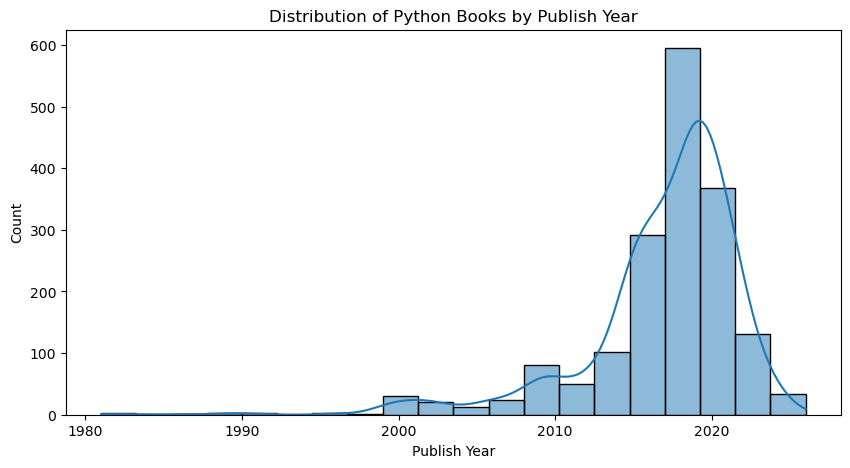

In [231]:
plt.figure(figsize=(10,5))
sns.histplot(df['first_publish_year'], bins=20, kde=True)
plt.title("Distribution of Python Books by Publish Year")
plt.xlabel("Publish Year")
plt.ylabel("Count")
plt.show()

# Books With Multiple Editions

# Interpretation 
Most Python books have fewer than 10 editions, while only a few highly popular books have many editions.

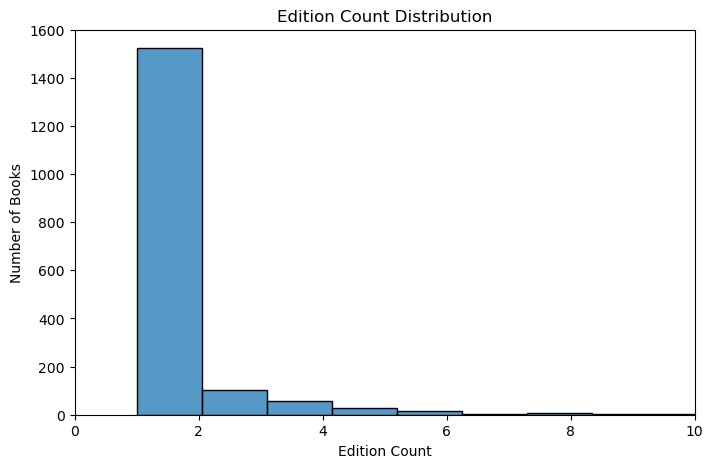

In [239]:
plt.figure(figsize=(8,5))
sns.histplot(df['edition_count'], bins=20)
plt.xlim(0,10)
plt.title("Edition Count Distribution")
plt.xlabel("Edition Count")
plt.ylabel("Number of Books")
plt.show()

# Top 10 authors 

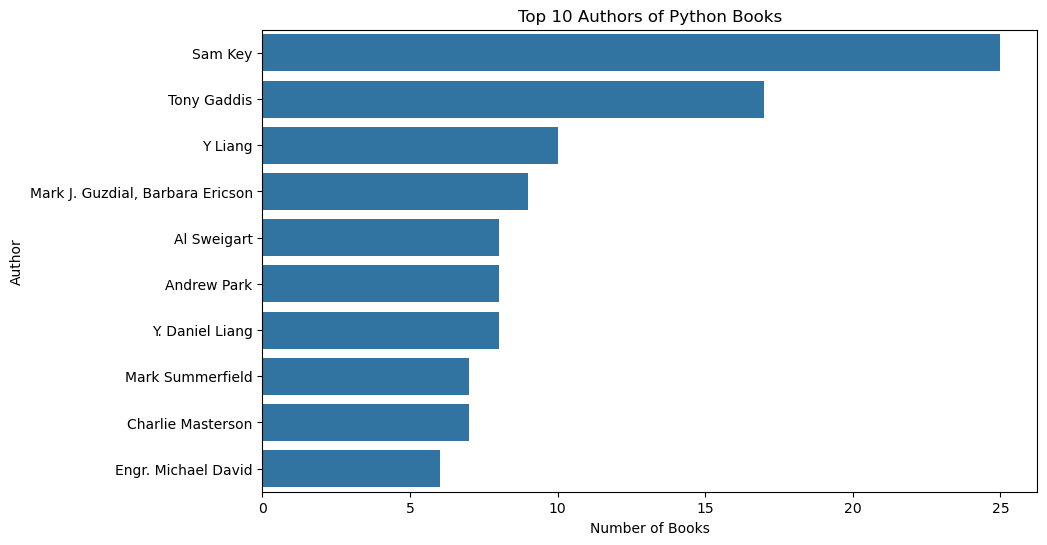

In [215]:
top_authors = df['author_name'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_authors.values, y=top_authors.index)
plt.title("Top 10 Authors of Python Books")
plt.xlabel("Number of Books")
plt.ylabel("Author")
plt.show() 

# Multiple editions availability

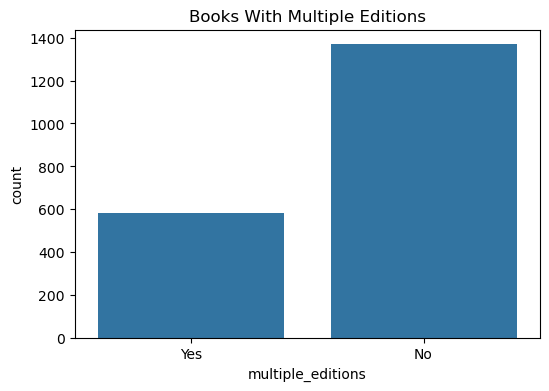

In [216]:
plt.figure(figsize=(6,4))
sns.countplot(x='multiple_editions', data=df)
plt.title("Books With Multiple Editions")
plt.show()

# Books Available in English i.e Primary Language

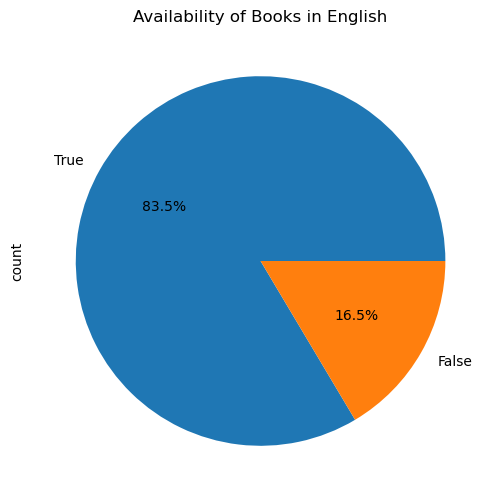

In [217]:
plt.figure(figsize=(10,6))
df['Availability_in_English'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Availability of Books in English")
plt.show()


# question : if u guys go to any other state which language do u guys prrefer to communicate ?

# Editions by Ebook Availability

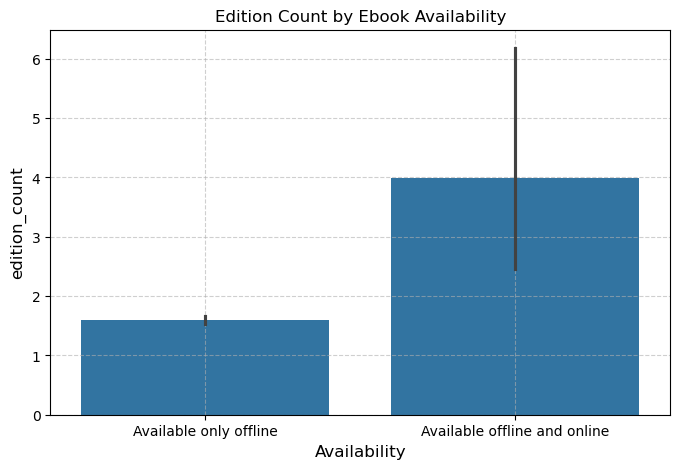

In [218]:
plt.figure(figsize=(8,5))
sns.barplot(x='availability', y='edition_count', data=df)
plt.title("Edition Count by Ebook Availability")
plt.xlabel('Availability',fontsize=12)
plt.ylabel('edition_count',fontsize =12)
plt.grid(True,linestyle='--',alpha=0.6)
plt.show()


#question : do u guys prefer reading from soft or hard copy ? 

# Publish year vs edition count

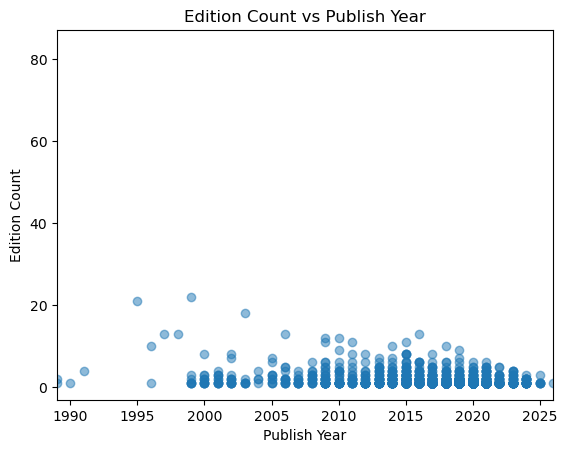

In [219]:
plt.scatter(df['first_publish_year'], df['edition_count'],alpha = 0.5)
plt.xlabel("Publish Year")
plt.xlim(1989,2026)
plt.ylabel("Edition Count")
plt.title("Edition Count vs Publish Year")
plt.show()



# for ppt question can someone tell which year python came ini.e developed ???

# Top years with most books

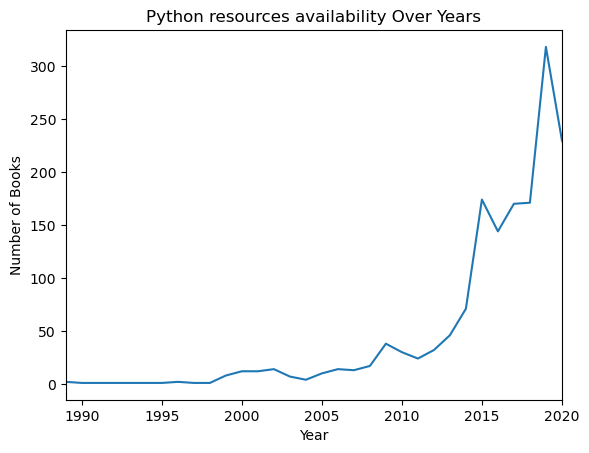

In [220]:
year_counts = df['first_publish_year'].value_counts().sort_index()

plt.plot(year_counts.index, year_counts.values)
plt.title("Python resources availability Over Years")
plt.xlabel("Year")
plt.xlim(1989,2020)
plt.ylabel("Number of Books")
plt.show()

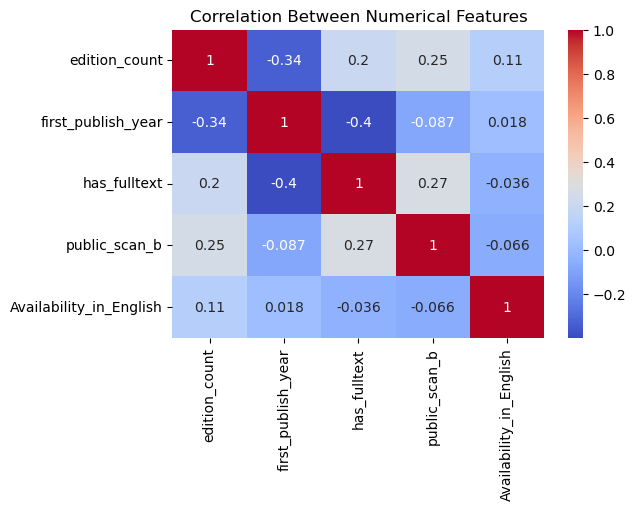

In [221]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Between Numerical Features")
plt.show()


In [222]:
# Keep only books that have 'Python' in the title
df = df[df['title'].str.contains('Python', case=False, na=False)]
df.size

19228

In [223]:
df

,author_name,ebook_access,edition_count,first_publish_year,has_fulltext,public_scan_b,title,available_languages,Availability_in_English,availability,multiple_editions
0,R. Nageswara Rao,no_ebook,5,2016,False,False,Core Python Programming,"hin, eng",True,Available only offline,Yes
1,Wesley Chun,printdisabled,2,2006,True,False,Core Python programming,eng,True,Available only offline,Yes
2,"Justin Seitz, Tim Arnold",borrowable,3,2014,True,False,Black Hat Python,"eng, pol",True,Available offline and online,Yes
3,Reema Thareja,no_ebook,2,2019,False,False,Python Programming,eng,True,Available only offline,Yes
4,Joshua Welsh,no_ebook,1,2017,False,False,Python,eng,True,Available only offline,No
...,...,...,...,...,...,...,...,...,...,...,...
1989,Roberto Ulloa,no_ebook,1,2015,False,False,Kivy – Interactive Applications and Games in P...,No info available,False,Available only offline,No
1994,Daniel Rubio,no_ebook,1,2017,False,False,Beginning Django: Web Application Development ...,No info available,False,Available only offline,No
1995,Michael Bowles,no_ebook,1,2015,False,False,Machine Learning in Python: Essential Techniqu...,No info available,False,Available only offline,No
1998,Prateek Joshi,printdisabled,4,2016,True,False,Python Machine Learning Cookbook,eng,True,Available only offline,Yes


In [224]:
pivot = pd.pivot_table(
    df,
    index='author_name',
    values=['title','edition_count','Availability_in_English'],
    aggfunc={
        'title':'count',
        'edition_count':'sum',
        'Availability_in_English':'sum'
    }
)

pivot = pivot.rename(columns={
    'title':'books_published',
    'edition_count':'total_editions',
    'Availability_in_English':'english_books'
})

pivot = pivot.sort_values(by='total_editions', ascending=False).head()

pivot

,english_books,total_editions,books_published
author_name,,,
Tony Gaddis,14,24,17
Mark Lutz,3,24,3
Sam Key,24,24,24
"Mark Lutz, David Ascher",1,22,1
Al Sweigart,4,19,8


# Box Plot

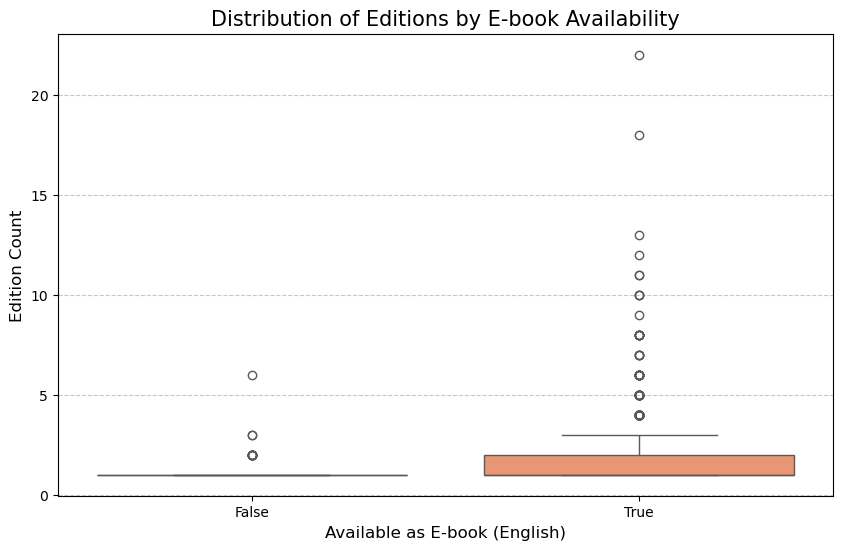

In [225]:

plt.figure(figsize=(10, 6))
sns.boxplot(x='Availability_in_English', y='edition_count', data=df, palette='Set2')

plt.title('Distribution of Editions by E-book Availability', fontsize=15)
plt.xlabel('Available as E-book (English)', fontsize=12)
plt.ylabel('Edition Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()